In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
import matplotlib.patches as patches

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('physrev_noticks.mplstyle')
plt.rcParams.update({"figure.figsize": [3.25, 1.01]})
plt.rcParams['figure.dpi'] = "300"

model_names = ["SubATTM", "SubCTRW", "SubFBM", "SubSBM", "SupFBM", "SupLW", "SupSBM", "STDBM"]
stat_names = ["AC","CS","SG","VD"]

In [2]:
def vis(base_path, tag_index, inverse=False, verbose=False):
    if inverse:
        inverse = "inverse_"
        title = "Low value disturb results (Acc drop)"
    else:
        inverse = ""
        title = "High value disturb results (Acc drop)"
        
    base_df = dict(np.load(f"{base_path}/disturb_acc_dict_mse_{inverse}base_{tag_index}.npy", allow_pickle=True).item())
    base_df = pd.DataFrame(base_df, index=stat_names)
    base_df.columns = model_names
    
    df = dict(np.load(f"{base_path}/disturb_acc_dict_mse_{inverse}{tag_index}.npy", allow_pickle=True).item())
    df = pd.DataFrame(df, index=stat_names)
    df.columns = model_names
    
    heatmap_data = base_df - df
    # if lower or equal to threshold, set to zero
    heatmap_data = heatmap_data*100
    heatmap_data = heatmap_data[["STDBM", "SubATTM", "SubCTRW", "SubFBM", "SubSBM", "SupFBM", "SupLW", "SupSBM"]]
    for_heatmap_data = heatmap_data.copy()
    # Get minimum and maximum values
    # if verbose:
    #     heatmap_vis(heatmap_data, title)

    return heatmap_data

In [3]:
def heatmap_vis(heatmap_data, title, colors=None, 
                highlight=False, highlight_color="red"):
    if colors is None:
        colors = [(1, 1, 1), (1, 0.4, 0.4)]  # Blue -> White -> Red
        
    # Get minimum and maximum values
    data_min, data_max = heatmap_data.min().min(), heatmap_data.max().max()
    # Define color gradient
    norm = Normalize(vmin=data_min, vmax=data_max)
    
    custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    ax = sns.heatmap(heatmap_data, annot=True, cmap=custom_cmap, norm=norm, linewidths=0.1,
                    linecolor='white', fmt='.2f', cbar=True, annot_kws={"size": 6})
    if highlight:
    # Highlight the max value in each column
        min_linewidth = 0.5           # Minimum line width for the border
        max_linewidth = 2  

        df = heatmap_data
        max_value = df.max().max()  # Find the overall maximum value in the entire DataFrame
        
        for col in df.columns:
            max_idx = df[col].idxmax()
    
            # Find the row index of the maximum value in the column
            row_pos = df.index.get_loc(max_idx)  # Integer index for the row
            col_pos = df.columns.get_loc(col)   # Integer index for the column

            col_max_value = df[col].max()
            scaled_linewidth = min_linewidth + (col_max_value / max_value) * (max_linewidth - min_linewidth)

            # Create a rectangle to highlight the cell with the maximum value
            rect = patches.Rectangle(
                (col_pos, row_pos),  # Position (x, y)
                1,                   # Width of the cell (always 1 for a single cell)
                1,                   # Height of the cell (always 1 for a single cell)
                linewidth=scaled_linewidth,         # Border width
                edgecolor=highlight_color,     # Border color
                facecolor='none',    # No fill color
                linestyle='--'       # Dashed line style (can be solid if desired)
            )
            
            # Add the rectangle to the axes
            ax.add_patch(rect)
    ax.set_yticklabels(["AC", "CS", "SG", "VD"], ha="right")

    
    plt.title(title)
    
    plt.xlabel("")
    plt.ylabel("")
    plt.show()

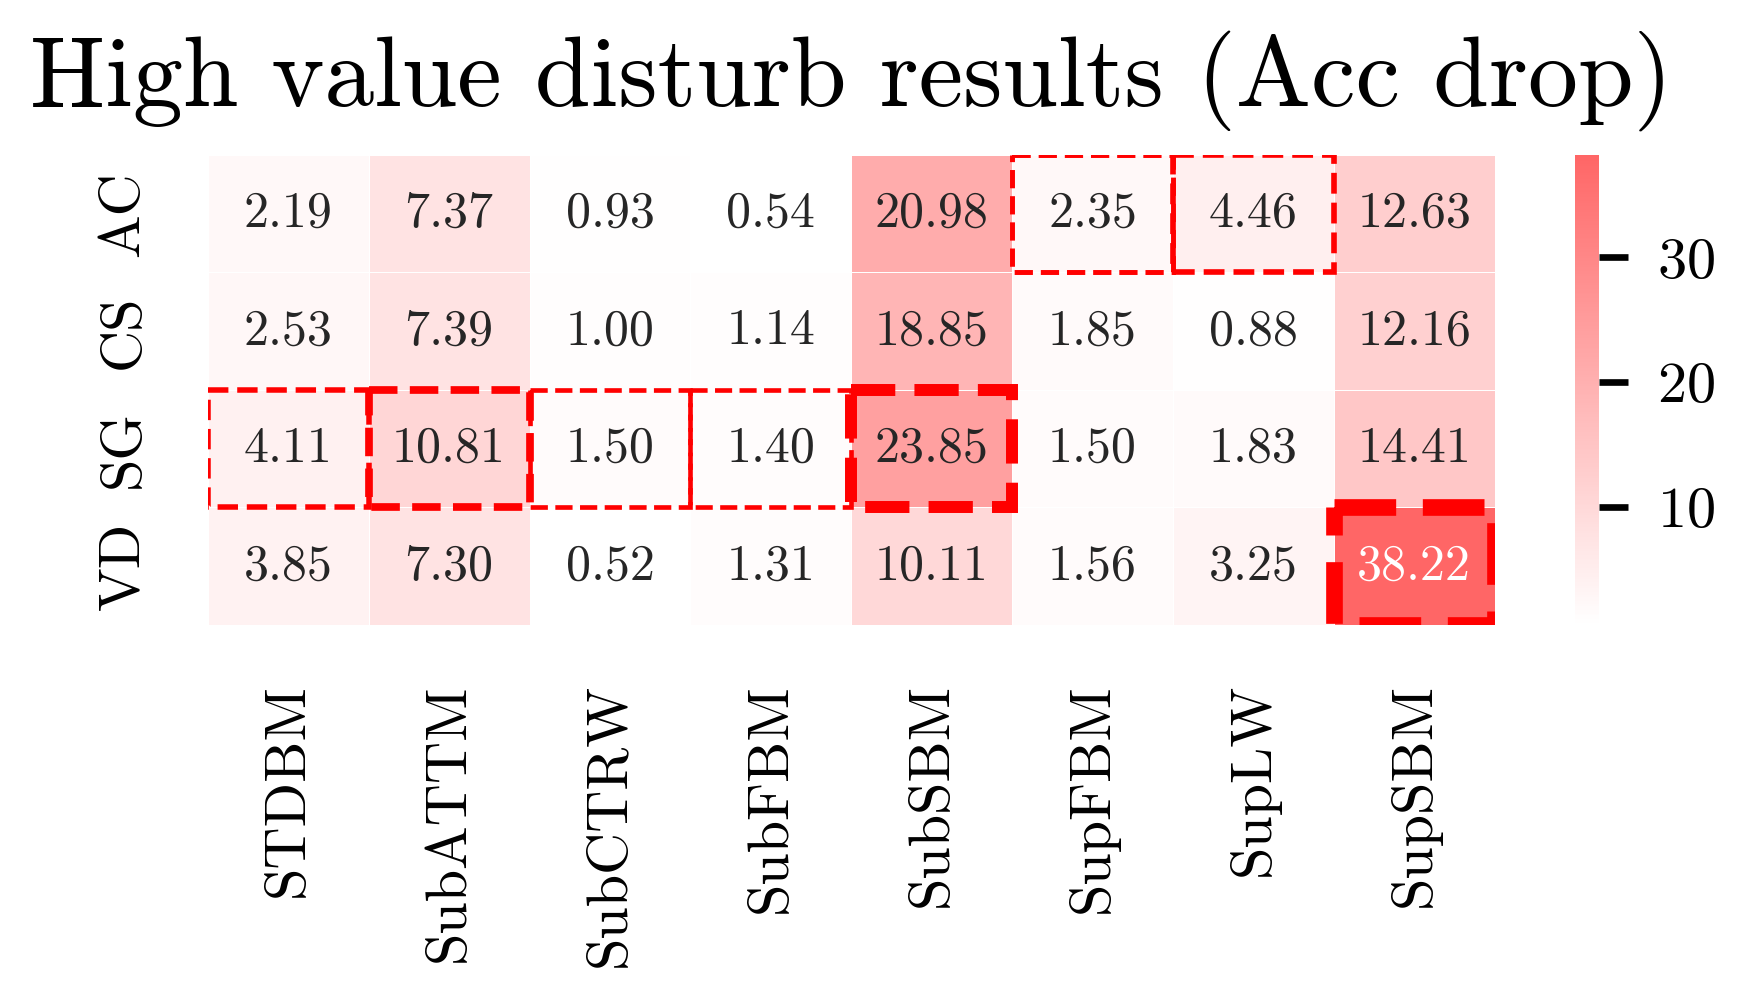

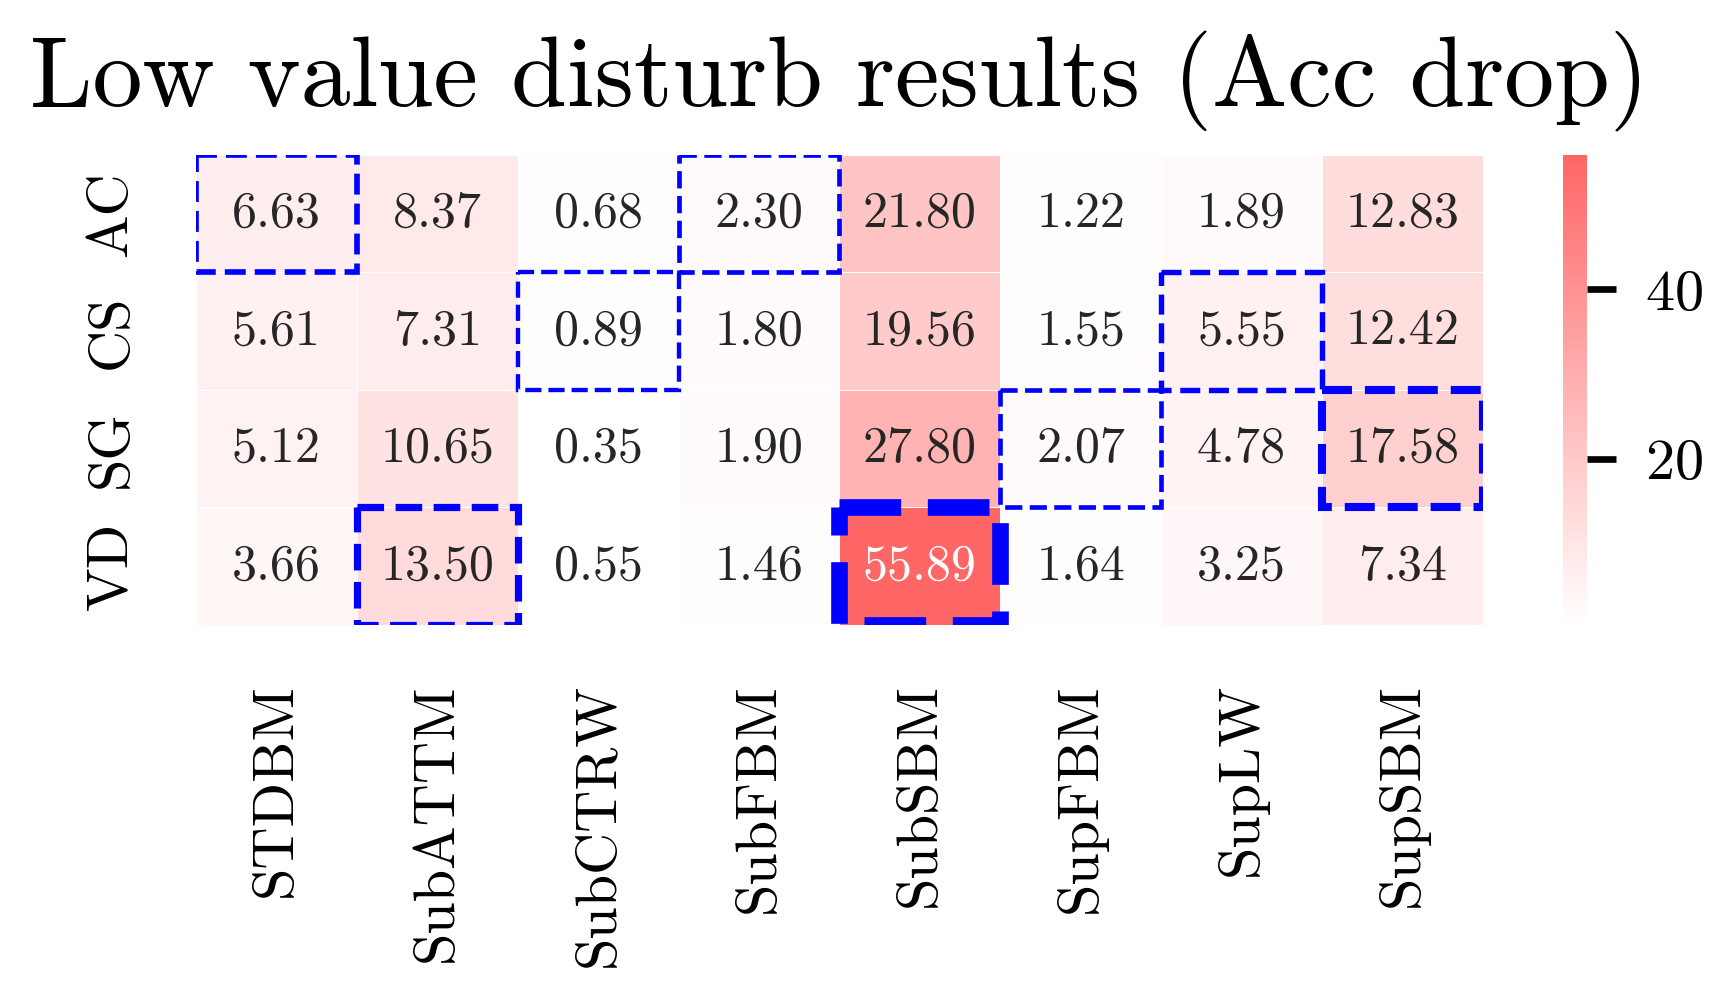

In [4]:
heatmap_for_tot = None
heatmap_inv_tot = None
for i in range(5):
    base_path = "./analysis_results/feature_ablation/"
    heatmap_for = vis(base_path, i, inverse=False)
    heatmap_inv = vis(base_path, i, inverse=True)
    if heatmap_for_tot is None:
        heatmap_for_tot = heatmap_for
        heatmap_inv_tot = heatmap_inv
    else:
        heatmap_for_tot += heatmap_for
        heatmap_inv_tot += heatmap_inv

heatmap_for_tot = heatmap_for_tot/5
heatmap_inv_tot = heatmap_inv_tot/5
# percentile normalization
heatmap_vis(heatmap_for_tot, title = "High value disturb results (Acc drop)",
            highlight=True, highlight_color='red')


# percentile normalization
heatmap_vis(heatmap_inv_tot, title = "Low value disturb results (Acc drop)",
            highlight=True, highlight_color='blue')

In [5]:
total_confusion_dict = pd.DataFrame(np.load("analysis_results/feature_ablation/total_confusion_dict.npy", allow_pickle=True).item()).T
total_confusion_dict_inverse = pd.DataFrame(np.load("analysis_results/feature_ablation/total_confusion_dict_inverse.npy", allow_pickle=True).item()).T
# make element string only
total_confusion_dict = total_confusion_dict.map(lambda x: x.split("\n")[0])
total_confusion_dict_inverse = total_confusion_dict_inverse.map(lambda x: x.split("\n")[0])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

# ------------------------------

def _interp_colormap(d, info):
    """
    d: 0~1 강도
    info: 'neg' or 'pos'
    """
    d = float(np.clip(d, 0.0, 1.0))
    if str(info).lower().startswith("neg"):
        cmap_pts = np.array([
            (1.0, 1.0, 1.0),
            (0.95,0.95,1.0),
            (0.9, 0.9, 1.0),
            (0.4, 0.4, 1.0)
        ])
    else:  # pos
        cmap_pts = np.array([
            (1.0, 1.0, 1.0),
            (1.0, 0.95,0.95),
            (1.0, 0.9, 0.9),
            (1.0, 0.4, 0.4)
        ])
    xs = [0.0, 0.33, 0.66, 1.0]
    r = np.interp(d, xs, cmap_pts[:,0])
    g = np.interp(d, xs, cmap_pts[:,1])
    b = np.interp(d, xs, cmap_pts[:,2])
    return (r,g,b,1.0)


# ------------------------------
def _per_feature_extremes(spec, row_labels, col_labels):
    extremes = {col: {"vmin": None, "vmax": None} for col in col_labels}
    for col in col_labels:
        vals = []
        for row in row_labels:
            cell = spec.get(col, {}).get(row, {})
            v = cell.get("val", None)
            if v is None:
                continue
            if isinstance(v, (tuple, list)):
                for x in v:
                    if x is None: 
                        continue
                    try:
                        vals.append(float(x))
                    except Exception:
                        pass
            else:
                try:
                    vals.append(float(v))
                except Exception:
                    pass
        if len(vals) == 0:
            extremes[col]["vmin"] = 0.0
            extremes[col]["vmax"] = 1.0
        else:
            extremes[col]["vmin"] = float(np.min(vals))
            extremes[col]["vmax"] = float(np.max(vals))
    return extremes

# ------------------------------
# ------------------------------
def plot_from_spec_extreme(
    spec, 
    row_labels=("AC","CS","SG","VD"),
    fontsize=6, 
    figsize=(1.35*3.25, 1.4*1.01),
    savepath="./figures/feature_ablation_heatmap_extreme.pdf",
    draw_vgrid=True,
    vgrid_skip_indices=(2,4,6),
    repeat_single_dual=True,
    gamma=0.6,     # contrast parameter
    d_floor=0.15,  # minimum intensity (0~1)
    margin_up    = 0.05,  # distance from UL corner text to cell top edge
    margin_down  = 0.05,  # distance from LR corner text to cell bottom edge
    margin_side  = 0.05,  # left/right margin
    line_gap     = 0.08,  # gap between label and number
):
    col_labels = list(spec.keys())
    n_rows = len(row_labels)
    n_cols = len(col_labels)

    extremes = _per_feature_extremes(spec, row_labels, col_labels)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5) 
    ax.add_patch(Rectangle((-0.5, -0.5), n_cols, n_rows, fill=True, color=(1,1,1), lw=0))

    for j, col in enumerate(col_labels):
        vmin = extremes[col]["vmin"]
        vmax = extremes[col]["vmax"]
        denom = max(abs(vmin), abs(vmax))
        if denom <= 0:
            denom = 1.0

        for i, row in enumerate(row_labels):
            cell = spec.get(col, {}).get(row, {})
            val   = cell.get("val", None)
            annot = cell.get("annot", None)
            info  = cell.get("info", None)

            if isinstance(val, (tuple, list)):
                v_ul, v_lr = val if len(val) == 2 else (val[0], None)
            else:
                v_ul, v_lr = val, val if repeat_single_dual else (val, None)

            if isinstance(annot, (tuple, list)):
                a_ul, a_lr = annot if len(annot) == 2 else (annot[0], None)
            else:
                a_ul, a_lr = annot, annot if repeat_single_dual else (annot, None)

            if isinstance(info, (tuple, list)):
                s_ul, s_lr = info if len(info) == 2 else (info[0], None)
            else:
                s_ul, s_lr = info, info if repeat_single_dual else (info, None)

            x0, y0 = j - 0.5, i - 0.5
            x1, y1 = j + 0.5, i + 0.5

            def _strength(v):
                if v is None:
                    return None
                try:
                    vv = abs(float(v)) / float(denom)
                except Exception:
                    return None
                vv = (vv ** gamma)
                vv = max(d_floor, min(1.0, vv))
                return vv

            if (v_lr is None) or (s_lr is None):
                d = _strength(v_ul)
                if d is not None and s_ul is not None:
                    color = _interp_colormap(d, s_ul)
                    ax.add_patch(Rectangle((x0, y0), 1.0, 1.0, color=color, lw=0))
            else:
                d_ul = _strength(v_ul)
                if d_ul is not None and s_ul is not None:
                    color_ul = _interp_colormap(d_ul, s_ul)
                    tri_ul = Polygon([(x0,y0), (x1,y0), (x0,y1)], closed=True, color=color_ul, lw=0)
                    ax.add_patch(tri_ul)

                d_lr = _strength(v_lr)
                if d_lr is not None and s_lr is not None:
                    color_lr = _interp_colormap(d_lr, s_lr)
                    tri_lr = Polygon([(x1,y1), (x1,y0), (x0,y1)], closed=True, color=color_lr, lw=0)
                    ax.add_patch(tri_lr)

            ax.add_patch(Rectangle((x0, y0), 1.0, 1.0, fill=False, edgecolor='white', linewidth=0.6))

            if v_ul is not None:
                x_ul = j - margin_side  
                y_base = (i - 0.5) + margin_up
                if a_ul is not None:
                    ax.text(x_ul, y_base, f"({str(a_ul)})",
                            ha='left', va='bottom', fontsize=fontsize-0.2, clip_on=False)
                    ax.text(x_ul, y_base + line_gap, f"{float(v_ul):.2f}",
                            ha='left', va='bottom', fontsize=fontsize, clip_on=False)
                else:
                    ax.text(x_ul, y_base, f"{float(v_ul):.2f}",
                            ha='left', va='bottom', fontsize=fontsize, clip_on=False)

            if v_lr is not None:
                x_lr = j + margin_side
                y_base = (i + 0.5) - margin_down
                if a_lr is not None:
                    ax.text(x_lr, y_base, f"{float(v_lr):.2f}",
                            ha='right', va='top', fontsize=fontsize, clip_on=False)
                    ax.text(x_lr, y_base + line_gap, f"({str(a_lr)})",
                            ha='right', va='top', fontsize=fontsize-0.2, clip_on=False)
                else:
                    ax.text(x_lr, y_base, f"{float(v_lr):.2f}",
                            ha='right', va='top', fontsize=fontsize, clip_on=False)

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    default_fontsize = plt.rcParams['xtick.labelsize']

    ax.set_xticklabels(col_labels, rotation=90, fontsize=default_fontsize)
    ax.set_yticklabels(row_labels, rotation=0, ha="center", fontsize=default_fontsize)
    if draw_vgrid:
        for k in range(1, n_cols):
            if k in vgrid_skip_indices:
                continue
            ax.axvline(k-0.5, color='black', linestyle='-', linewidth=1.0)

    ax.add_patch(Rectangle((-0.5, -0.5), n_cols, n_rows, fill=False, edgecolor='black', linewidth=1.2))
    ax.set_facecolor('white')
    # plt.tight_layout()
    fig.subplots_adjust(left=0.06, right=0.995, top=0.99, bottom=0.23)


    if savepath:
        import os
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath)
    plt.show()


In [ ]:
import numpy as np

def build_spec_from_sources(
    heatmap_inv_tot: dict,
    heatmap_for_tot: dict,
    total_confusion_dict_inverse: dict,
    total_confusion_dict: dict,
    stat_names,
    features_order=("SubFBM","SupFBM","SupLW","SubCTRW","SubATTM","SubSBM","SupSBM"),
    dual_mode="pair",  # "pair": (inv, for) 대each선; "single": 주 소스 하나만 넣고 플롯에서 복제
):
    """
    heatmap_*: dict[str] -> pandas.Series(index=stat_names) or dict[row]->val
    total_confusion_*: dict[str] -> dict[row]->annot
    return spec
    """

    def _get_from_series_or_dict(container, key1, key2):
        """container[key1][key2]"""
        if container is None: return None
        if key1 not in container: return None
        obj = container[key1]
        try:
            # pandas.Series or dict
            if isinstance(obj, dict):
                return obj.get(key2, None)
            else:
                # assume Series-like
                return obj[key2]
        except Exception:
            return None

    primary_source = {
        "SubFBM": "inv",
        "SupFBM": "for",
        "SupLW" : "inv",
        "SubCTRW": "inv",  
        "SubATTM": "inv",
        "SubSBM": "inv",
        "SupSBM": "for",
    }

    spec = {}
    for feat in features_order:
        feat_block = {}
        for row in stat_names:
            v_inv = _get_from_series_or_dict(heatmap_inv_tot, feat, row)
            v_for = _get_from_series_or_dict(heatmap_for_tot, feat, row)

            a_inv = _get_from_series_or_dict(total_confusion_dict_inverse, feat, row)
            a_for = _get_from_series_or_dict(total_confusion_dict, feat, row)

            if dual_mode == "pair":
                ul_val = v_inv if v_inv is not None else v_for
                lr_val = v_for if v_for is not None else v_inv

                ul_annot = a_inv if a_inv is not None else a_for
                lr_annot = a_for if a_for is not None else a_inv

                ul_info = "neg" if v_inv is not None or a_inv is not None else "pos"
                lr_info = "pos" if v_for is not None or a_for is not None else "neg"

                if ul_val is None and lr_val is None and ul_annot is None and lr_annot is None:
                    continue

                def _to_float_or_none(x):
                    try:
                        return float(x)
                    except Exception:
                        return None

                ul_val = _to_float_or_none(ul_val)
                lr_val = _to_float_or_none(lr_val)

                feat_block[row] = {
                    "val":   (ul_val, lr_val),
                    "annot": (ul_annot, lr_annot),
                    "info":  (ul_info, lr_info),
                }

            else:  
                src = primary_source.get(feat, "inv")
                if src == "inv":
                    v = v_inv
                    a = a_inv
                    s = "neg"
                else:
                    v = v_for
                    a = a_for
                    s = "pos"

                try:
                    v = float(v) if v is not None else None
                except Exception:
                    v = None

                if v is None and a is None:
                    continue

                feat_block[row] = {
                    "val": v,
                    "annot": a,
                    "info": s,
                }

        spec[feat] = feat_block

    return spec


In [ ]:
spec = build_spec_from_sources(
    heatmap_inv_tot=heatmap_inv_tot,
    heatmap_for_tot=heatmap_for_tot,
    total_confusion_dict_inverse=total_confusion_dict_inverse,
    total_confusion_dict=total_confusion_dict,
    stat_names=stat_names,
    features_order=("SubFBM","SupFBM","SupLW","SubCTRW","SubATTM","SubSBM","SupSBM"),
    dual_mode="pair",  
)


In [9]:

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('physrev_noticks.mplstyle')
plt.rcParams.update({"figure.figsize": [3.25*2, 1.01*2]})
plt.rcParams['figure.dpi'] = "300"

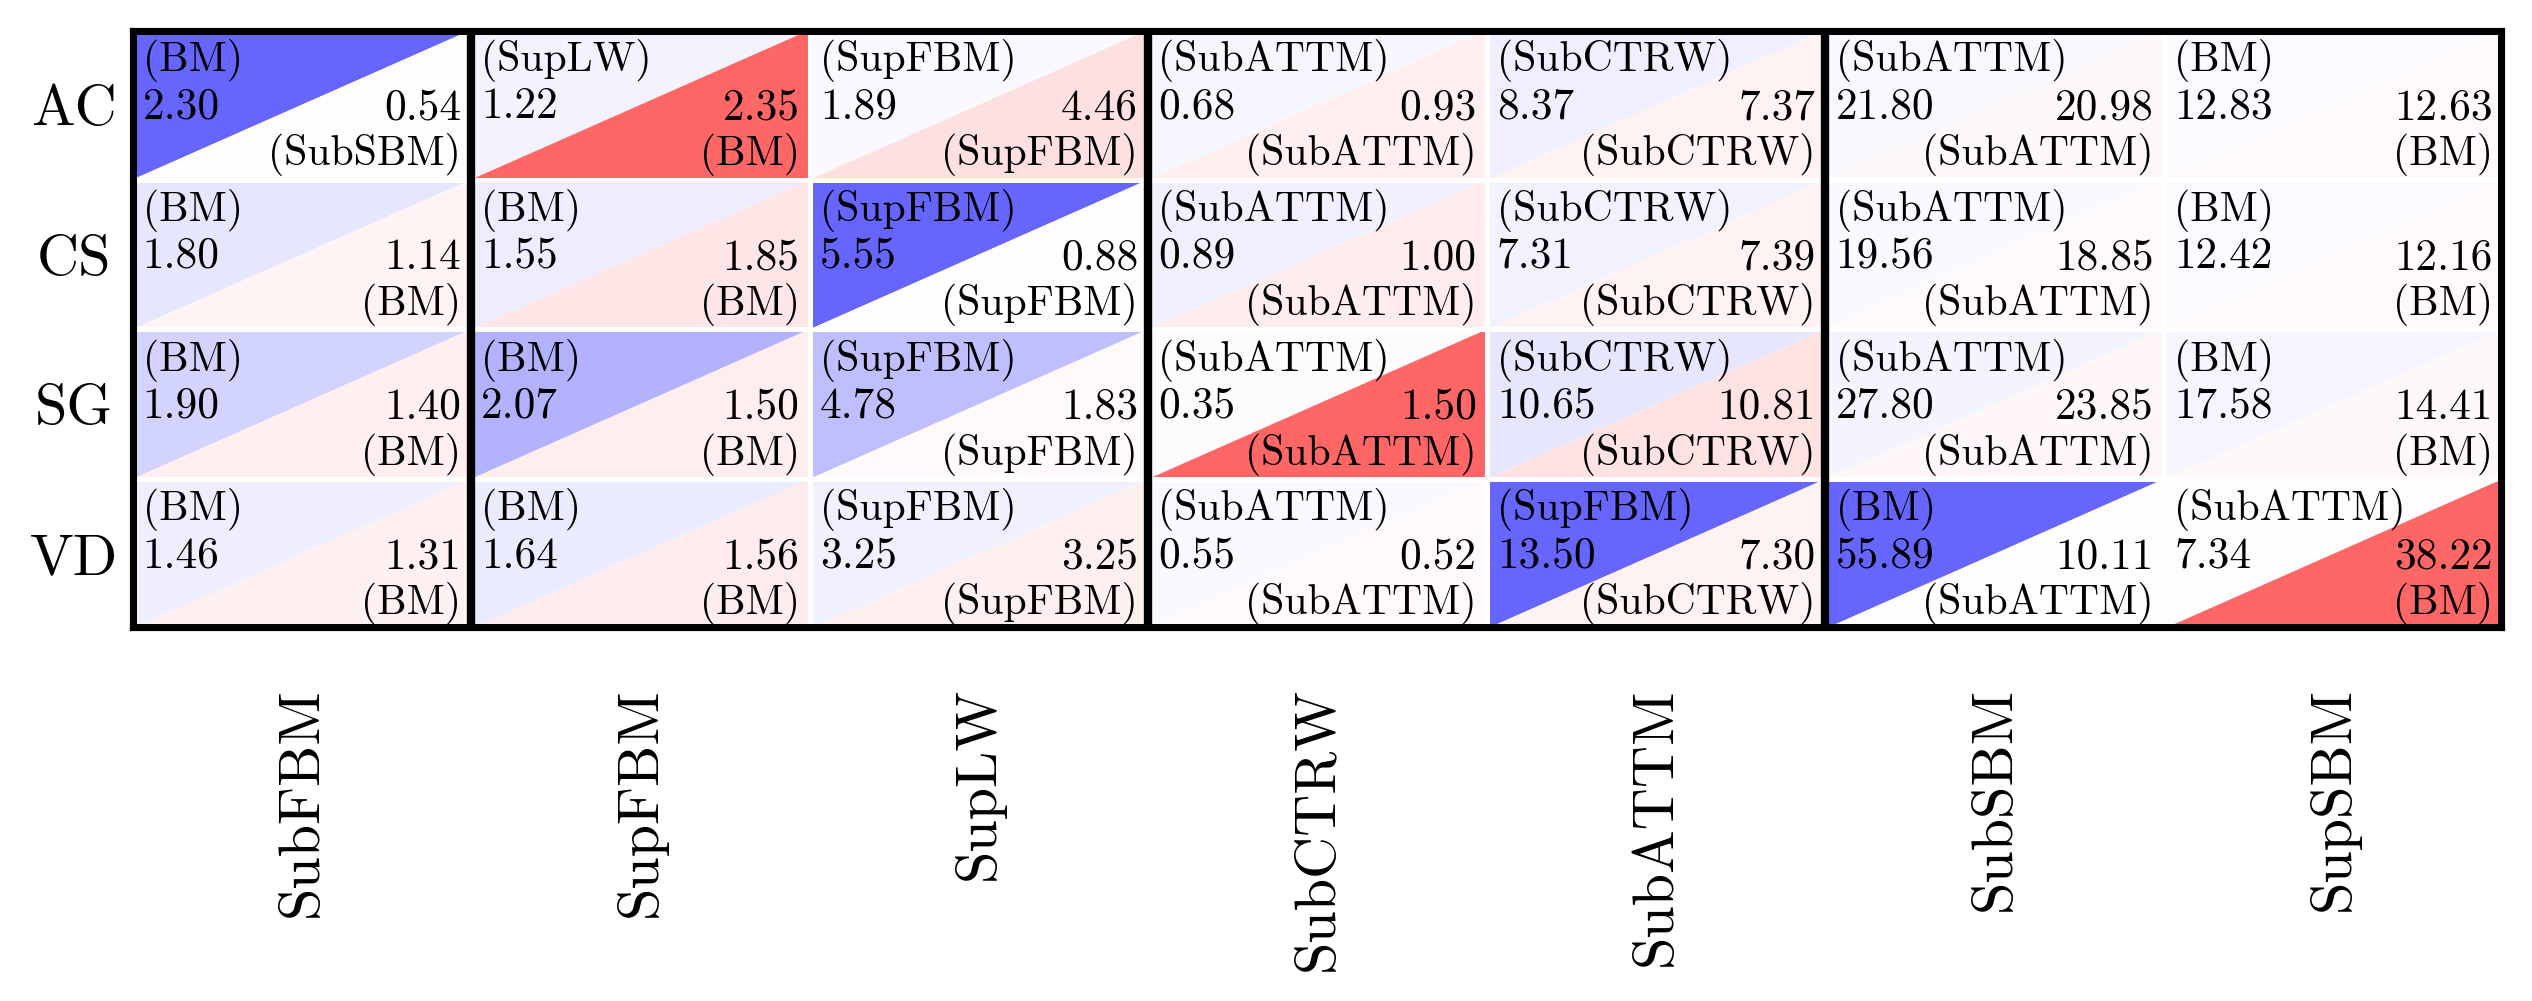

In [ ]:
plot_from_spec_extreme(
    spec,
    row_labels=("AC","CS","SG","VD"),
    fontsize=5.2,
    figsize=(3.25*1.3, 1.01*1.3),
    savepath="./figures/feature_ablation_heatmap_extreme.pdf",
    draw_vgrid=True,
    vgrid_skip_indices=(2,4,6),
    repeat_single_dual=True,
    gamma=1.8,
    d_floor=0.0,
    margin_up    = 0.35,  
    margin_down  = 0.61,
    margin_side  = 0.47,
    line_gap     = 0.3,
)